# Project 1: LLM Core Foundations & Interactive AI Studio
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com)
[![Google GenAI SDK](https://img.shields.io/badge/SDK-google--genai%20v1.0+-blue.svg)](https://github.com/googleapis/python-genai)
[![Models](https://img.shields.io/badge/Models-Gemini%203.8%20%7C%20Gemini%203.8-orange.svg)](https://ai.google.dev)

---

## 🌟 Welcome to Your First Applied AI Engineering Project!
If you have ever wondered **"How does ChatGPT or Google Gemini actually generate text?"** or **"What does temperature really do under the hood?"**, you are in the right place.

In this project, we strip away the intimidating academic jargon and build a rock-solid mental model of Large Language Models (LLMs). Then, we will write clean, production-grade Python code using Google's modern `google-genai` SDK to create an **Interactive LLM Playground**.

---

## 🏛️ How Large Language Models Generate Text

<p align="center">
  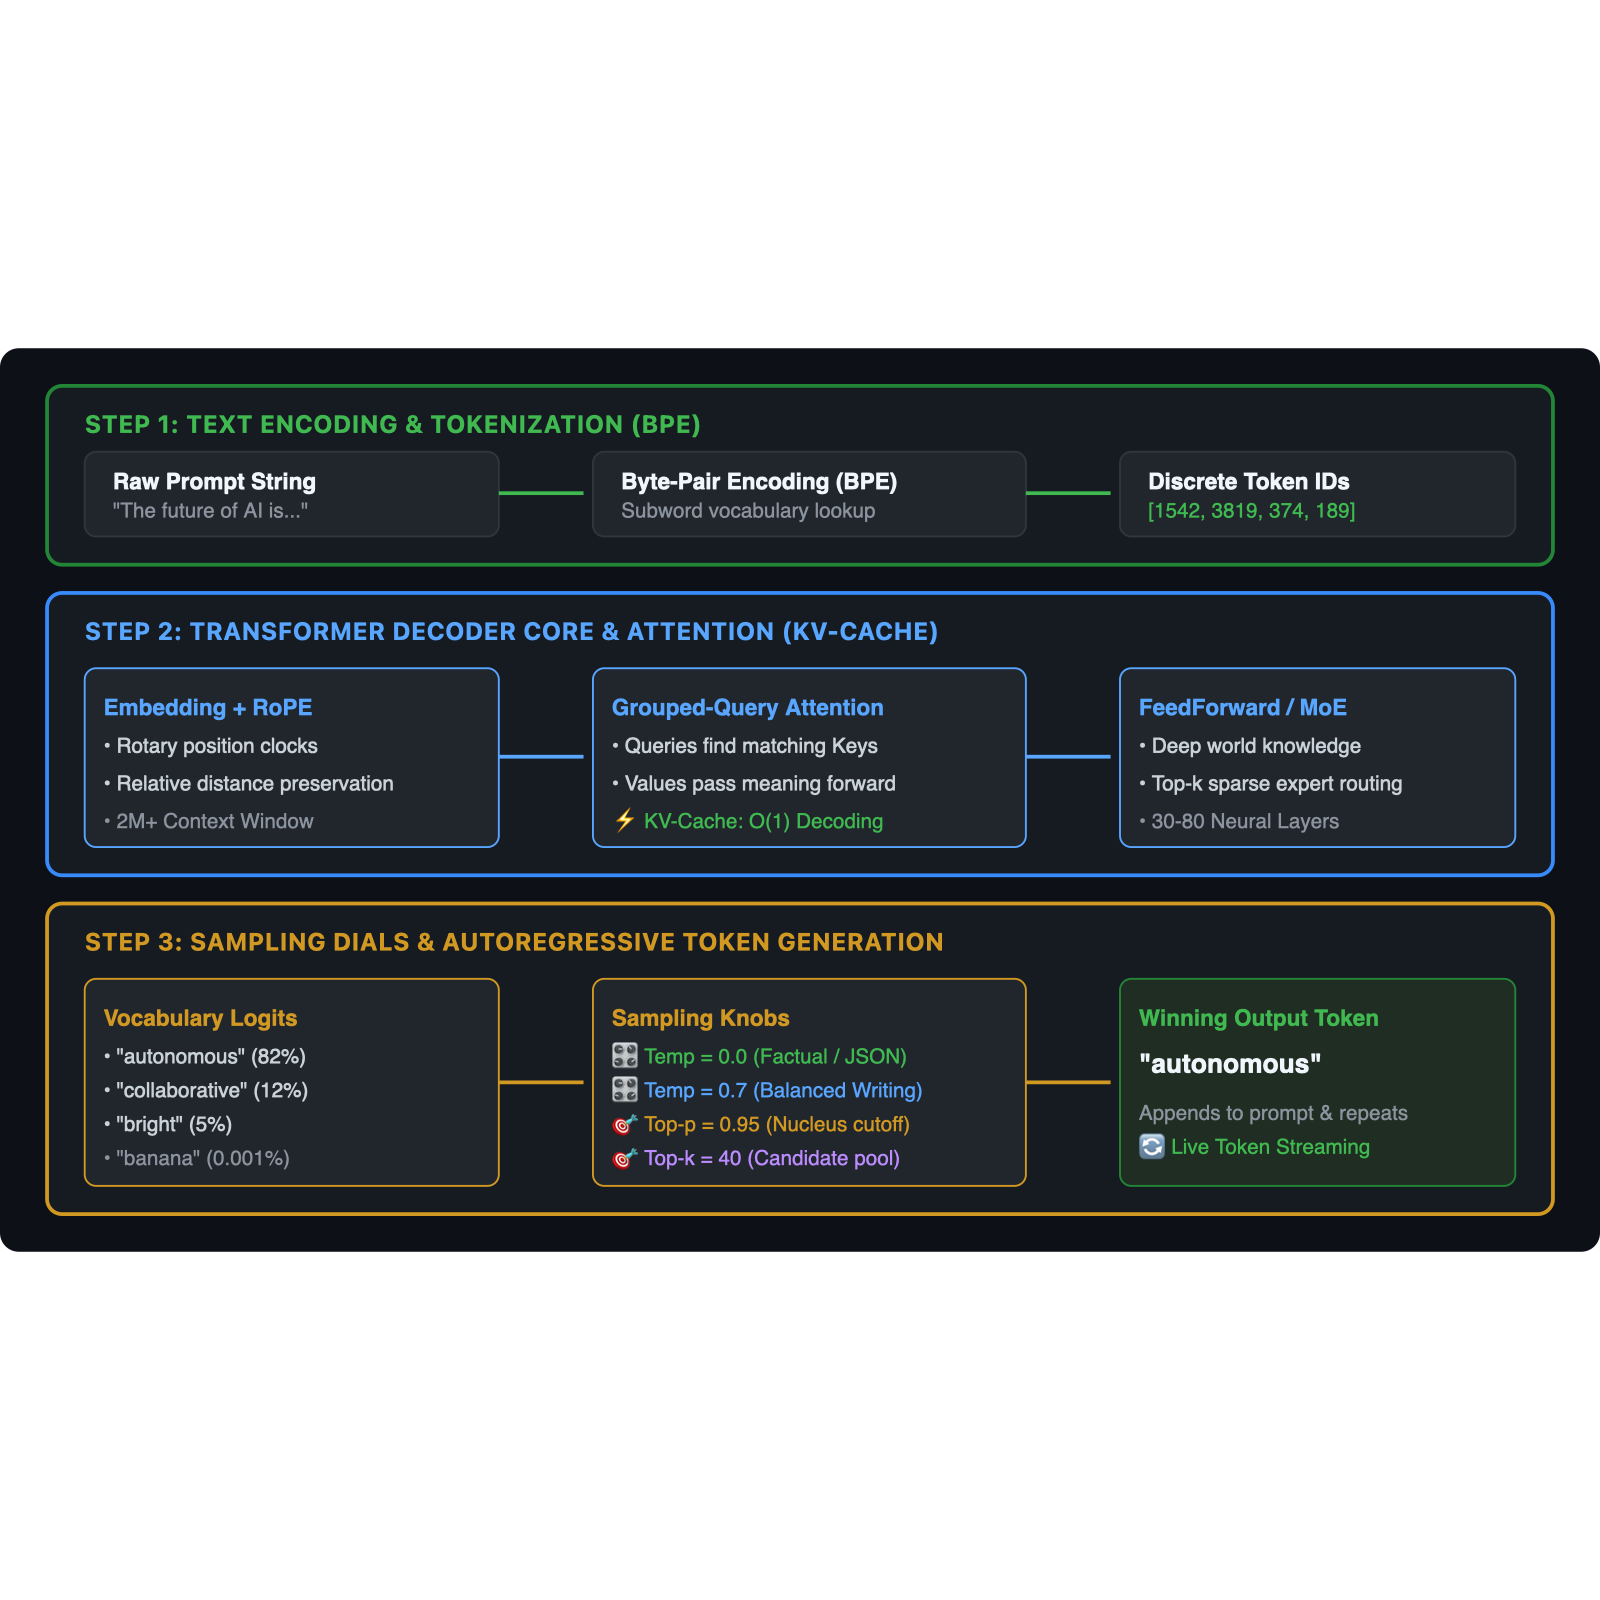
</p>

---

## 🗺️ Project Roadmap & What You Will Master
<p align="center">
  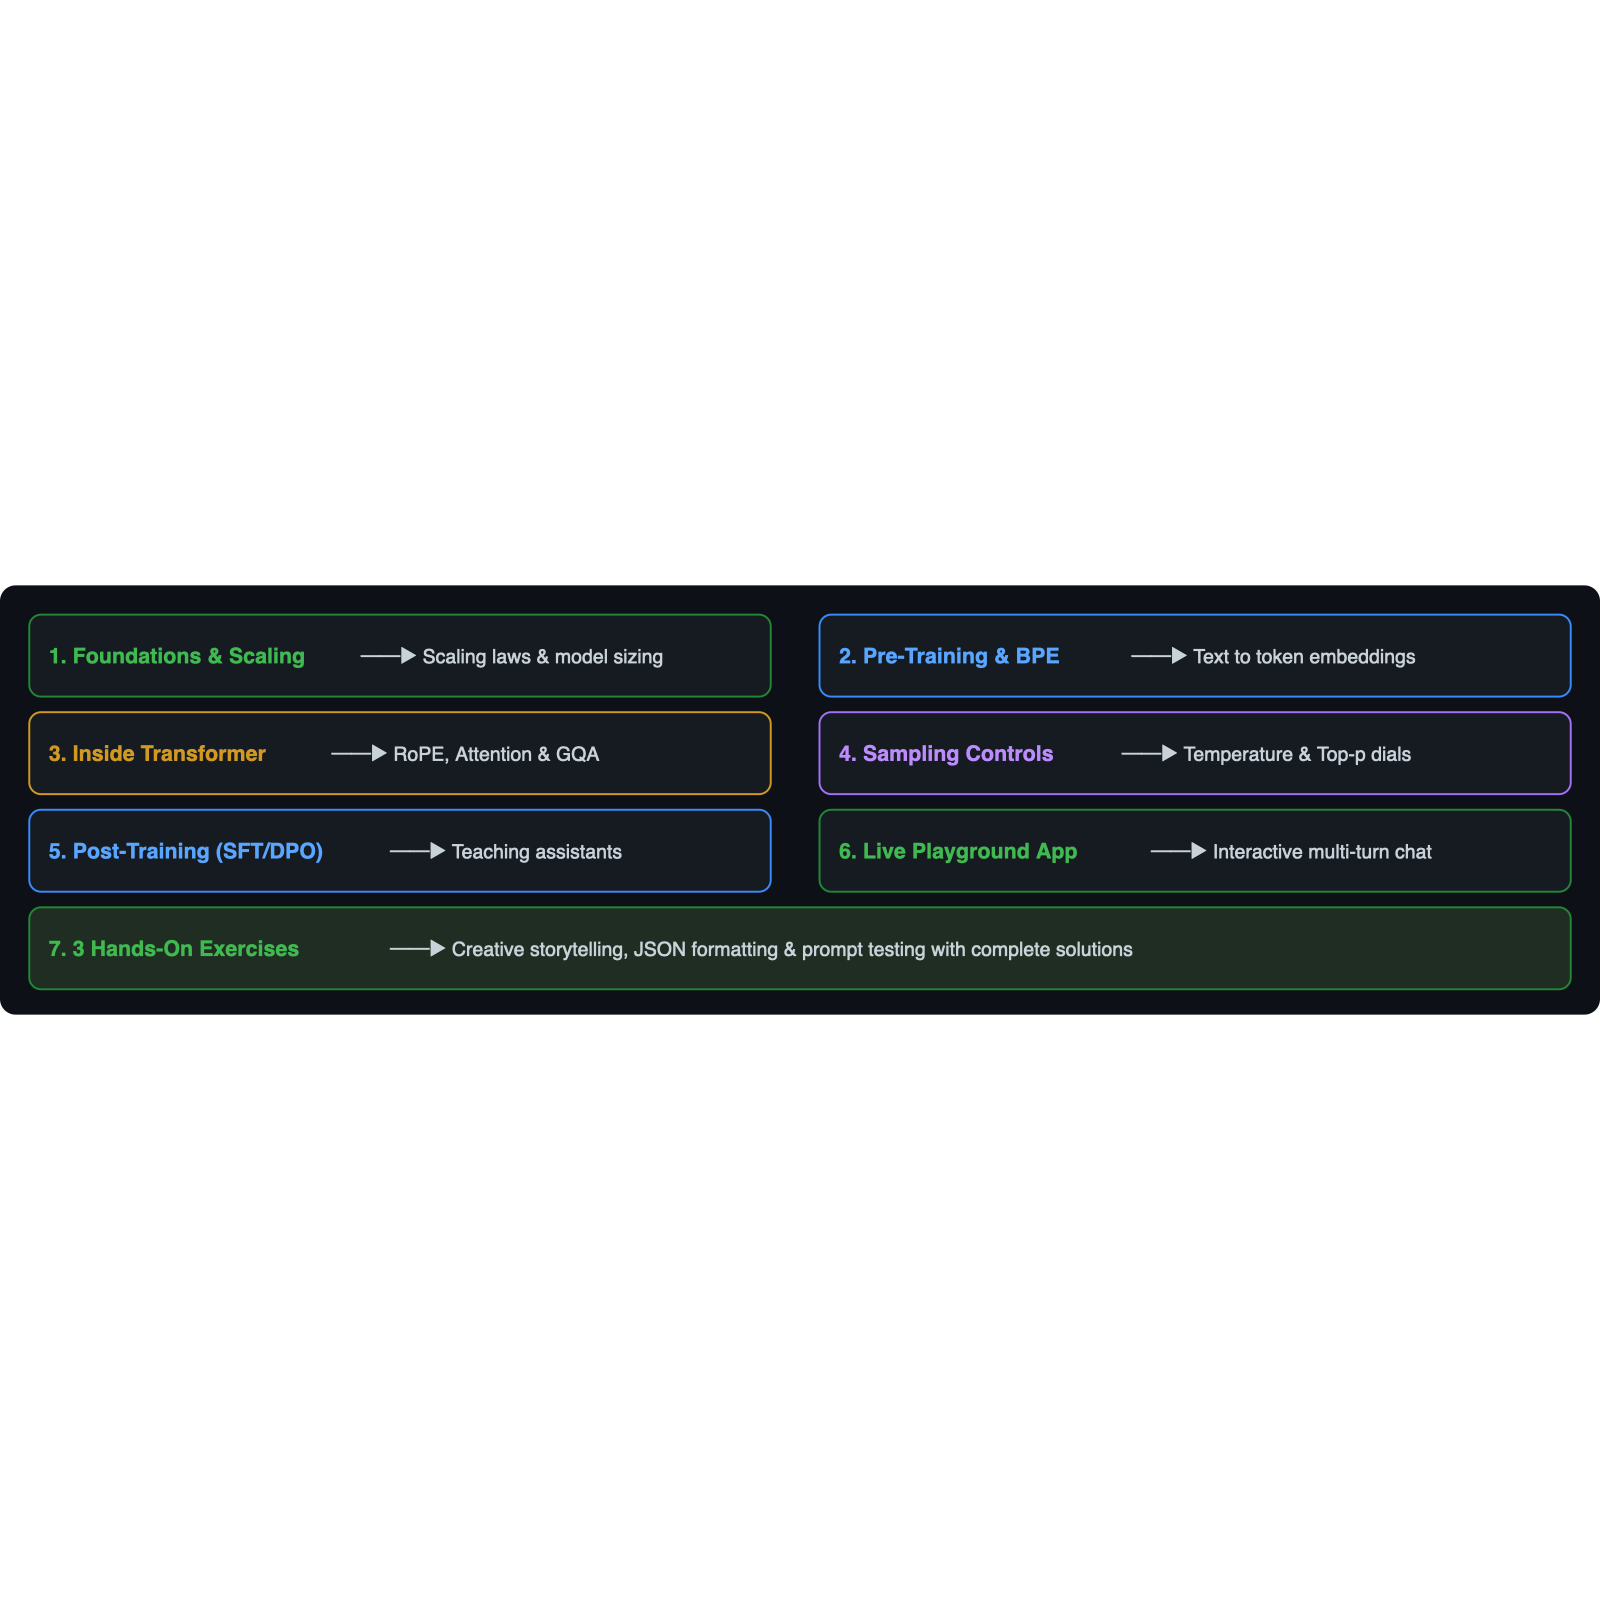
</p>


---
## Environment Setup & Initialization
We install the official Google GenAI SDK (`google-genai`) along with essential scientific, visualization, and interface libraries.


In [ ]:
# Install the modern google-genai SDK and helper packages
!pip install -q google-genai pydantic tiktoken matplotlib seaborn ipywidgets rich


---
## ⚡ Quickstart: The 30-Second Micro-Example

Before we dive into theory, let's see how simple it is to generate text with Google's modern `google-genai` SDK in just **3 lines of code**:

```python
from google import genai

client = genai.Client()  # Automatically picks up GEMINI_API_KEY from environment
response = client.models.generate_content(
    model="gemini-3.8-flash", 
    contents="Explain why the sky is blue in one sentence."
)
print(response.text)
```

Let's set up our client and run our first call!


In [ ]:
import os
import getpass
from google import genai
from google.genai import types

# Authenticate via API Key or Vertex AI
if "GEMINI_API_KEY" not in os.environ:
    # Prompt securely if not already in env
    api_key = getpass.getpass("Enter your Gemini API Key (or press enter for Vertex AI auth): ")
    if api_key:
        os.environ["GEMINI_API_KEY"] = api_key

# Initialize GenAI Client
if os.environ.get("GEMINI_API_KEY"):
    client = genai.Client()
    print("✅ Google GenAI Client initialized successfully via Google AI Studio API Key.")
else:
    # Vertex AI Fallback Configuration
    PROJECT_ID = os.environ.get("GOOGLE_CLOUD_PROJECT", "your-project-id")
    LOCATION = os.environ.get("GOOGLE_CLOUD_LOCATION", "us-central1")
    client = genai.Client(vertexai=True, project=PROJECT_ID, location=LOCATION)
    print(f"✅ Google GenAI Client initialized via Vertex AI (Project: {PROJECT_ID}, Region: {LOCATION}).")


---
## 2. The Pre-Training Pipeline: How Models Learn Language

### 2.1 The Data Journey: From Raw Web to High-Quality Knowledge
Before a model can speak, it reads trillions of words from the internet, books, code repositories, and scientific papers.

<p align="center">
  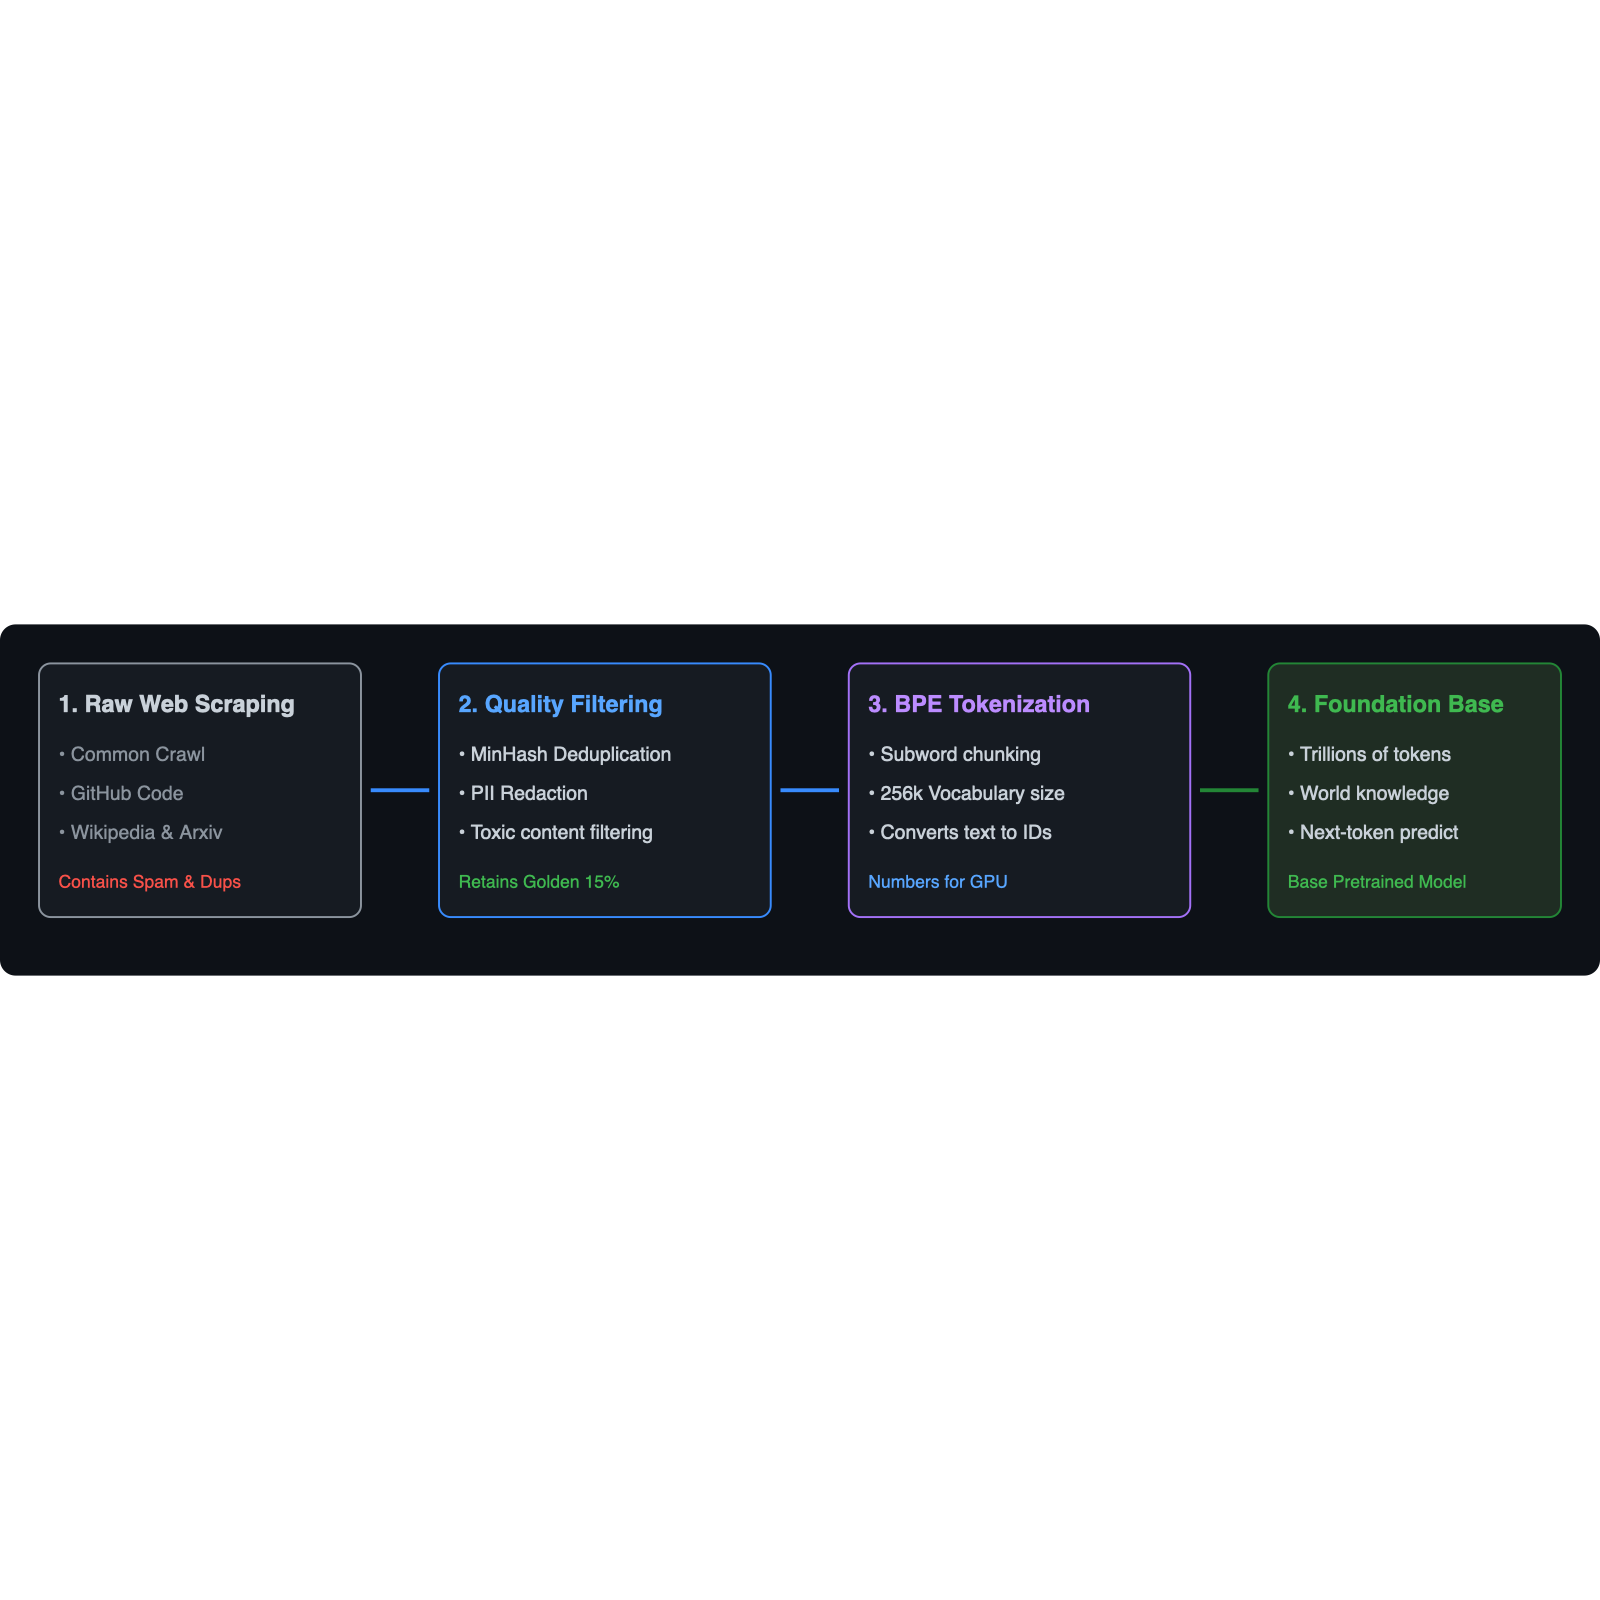
</p>

---

### 2.2 What is a Token? (Byte-Pair Encoding - BPE)
Computers cannot read letters or words directly; GPUs process mathematical vectors (arrays of numbers).

**Tokenization** is the translation layer:
- In English, **1 token $\approx$ 4 characters** or roughly **0.75 words**.
- Common words like `"the"`, `"apple"`, `"Google"` are single tokens.
- Rare or compound words get broken into subwords: `"unbelievable"` $\to$ `["un", "believ", "able"]`.


In [ ]:
from collections import Counter
import re

def get_stats(vocab):
    pairs = Counter()
    for word, freq in vocab.items():
        symbols = word.split()
        for i in range(len(symbols) - 1):
            pairs[symbols[i], symbols[i+1]] += freq
    return pairs

def merge_vocab(pair, v_in):
    v_out = {}
    bigram = re.escape(' '.join(pair))
    p = re.compile(r'(?<!\S)' + bigram + r'(?!\S)')
    for word in v_in:
        w_out = p.sub(''.join(pair), word)
        v_out[w_out] = v_in[word]
    return v_out

# Sample training corpus
corpus = "low lower newest widest lowest newer wider"
vocab = {' '.join(list(word)) + ' </w>': freq for word, freq in Counter(corpus.split()).items()}

print("Initial Tokenized Vocabulary:")
print(vocab)

num_merges = 6
bpe_merges = []
for i in range(num_merges):
    pairs = get_stats(vocab)
    if not pairs:
        break
    best_pair = max(pairs, key=pairs.get)
    vocab = merge_vocab(best_pair, vocab)
    bpe_merges.append(best_pair)
    print(f"Merge {i+1}: {best_pair} -> {''.join(best_pair)} (Freq: {pairs[best_pair]})")

print("\nFinal Vocabulary State:")
print(vocab)


---
## 3. Inside the Transformer: Attention & Architecture Made Simple

Modern models like **Gemini 3.8** and **Gemma** are built on the **Transformer Decoder** architecture. Let's demystify its four core components:

<p align="center">
  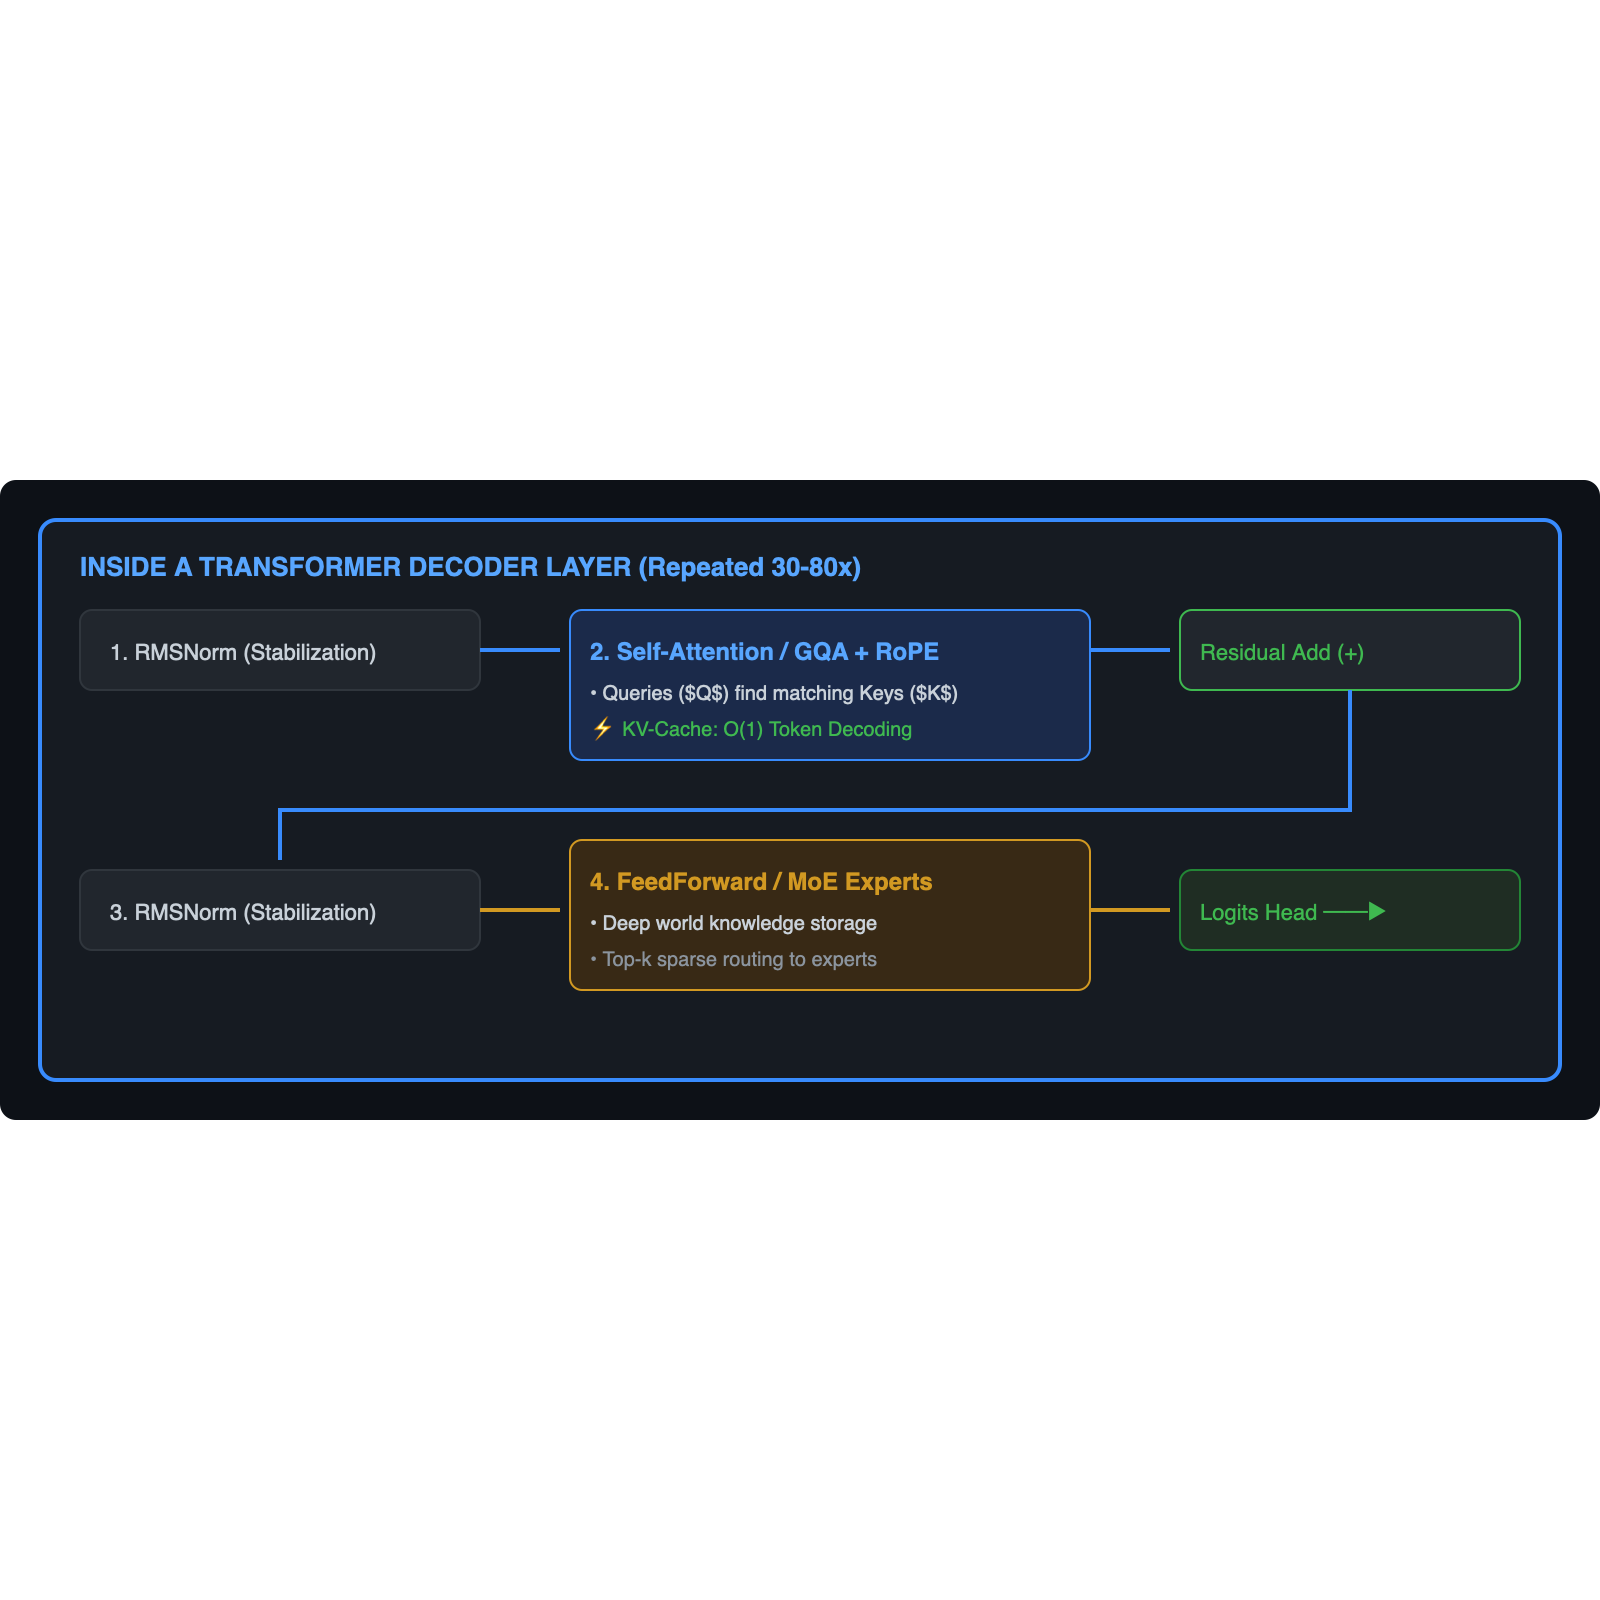
</p>

### 🧠 The 4 Core Architectural Concepts Every Applied AI Engineer Must Know:

#### 1. Self-Attention (Queries, Keys, and Values)
Think of Attention like a **search query inside the sentence**:
- **Query ($Q$)**: *"What am I looking for?"* (e.g. The pronoun `"it"` is looking for what object it refers to).
- **Key ($K$)**: *"What topics do I contain?"* (e.g. The word `"robot"` advertises its subject).
- **Value ($V$)**: *"The actual meaning information to pass along."*
- When Query and Key match, the model connects the words together!

#### 2. Rotary Position Embeddings (RoPE)
Words change meaning based on order (`"dog bites man"` vs `"man bites dog"`).  
**RoPE** rotates the numbers representing each word like the **hands on a clock** based on their position index. This lets the model naturally understand relative distance between words across millions of tokens!

#### 3. Grouped-Query Attention (GQA) & KV-Caching
- **The Problem**: In a standard conversation, calculating attention for 100,000 tokens uses enormous GPU memory bandwidth.
- **The Solution (KV-Cache)**: The GPU caches past tokens' Key & Value numbers in memory so it only processes the *single new token* being generated ($O(1)$ instead of $O(N^2)$).
- **Grouped-Query Attention (GQA)**: Multiple Query heads share the same Key/Value cache (e.g. 8 Queries share 1 KV). This slashes GPU memory usage by **up to 8x**, allowing blazing fast responses!


---
## 4. Text Generation & Sampling Mechanics: Mastering the Control Dials

Once the model computes scores (called **logits**) for every word in its vocabulary, how does it choose which word to print? This is controlled by **Sampling Parameters**.

<p align="center">
  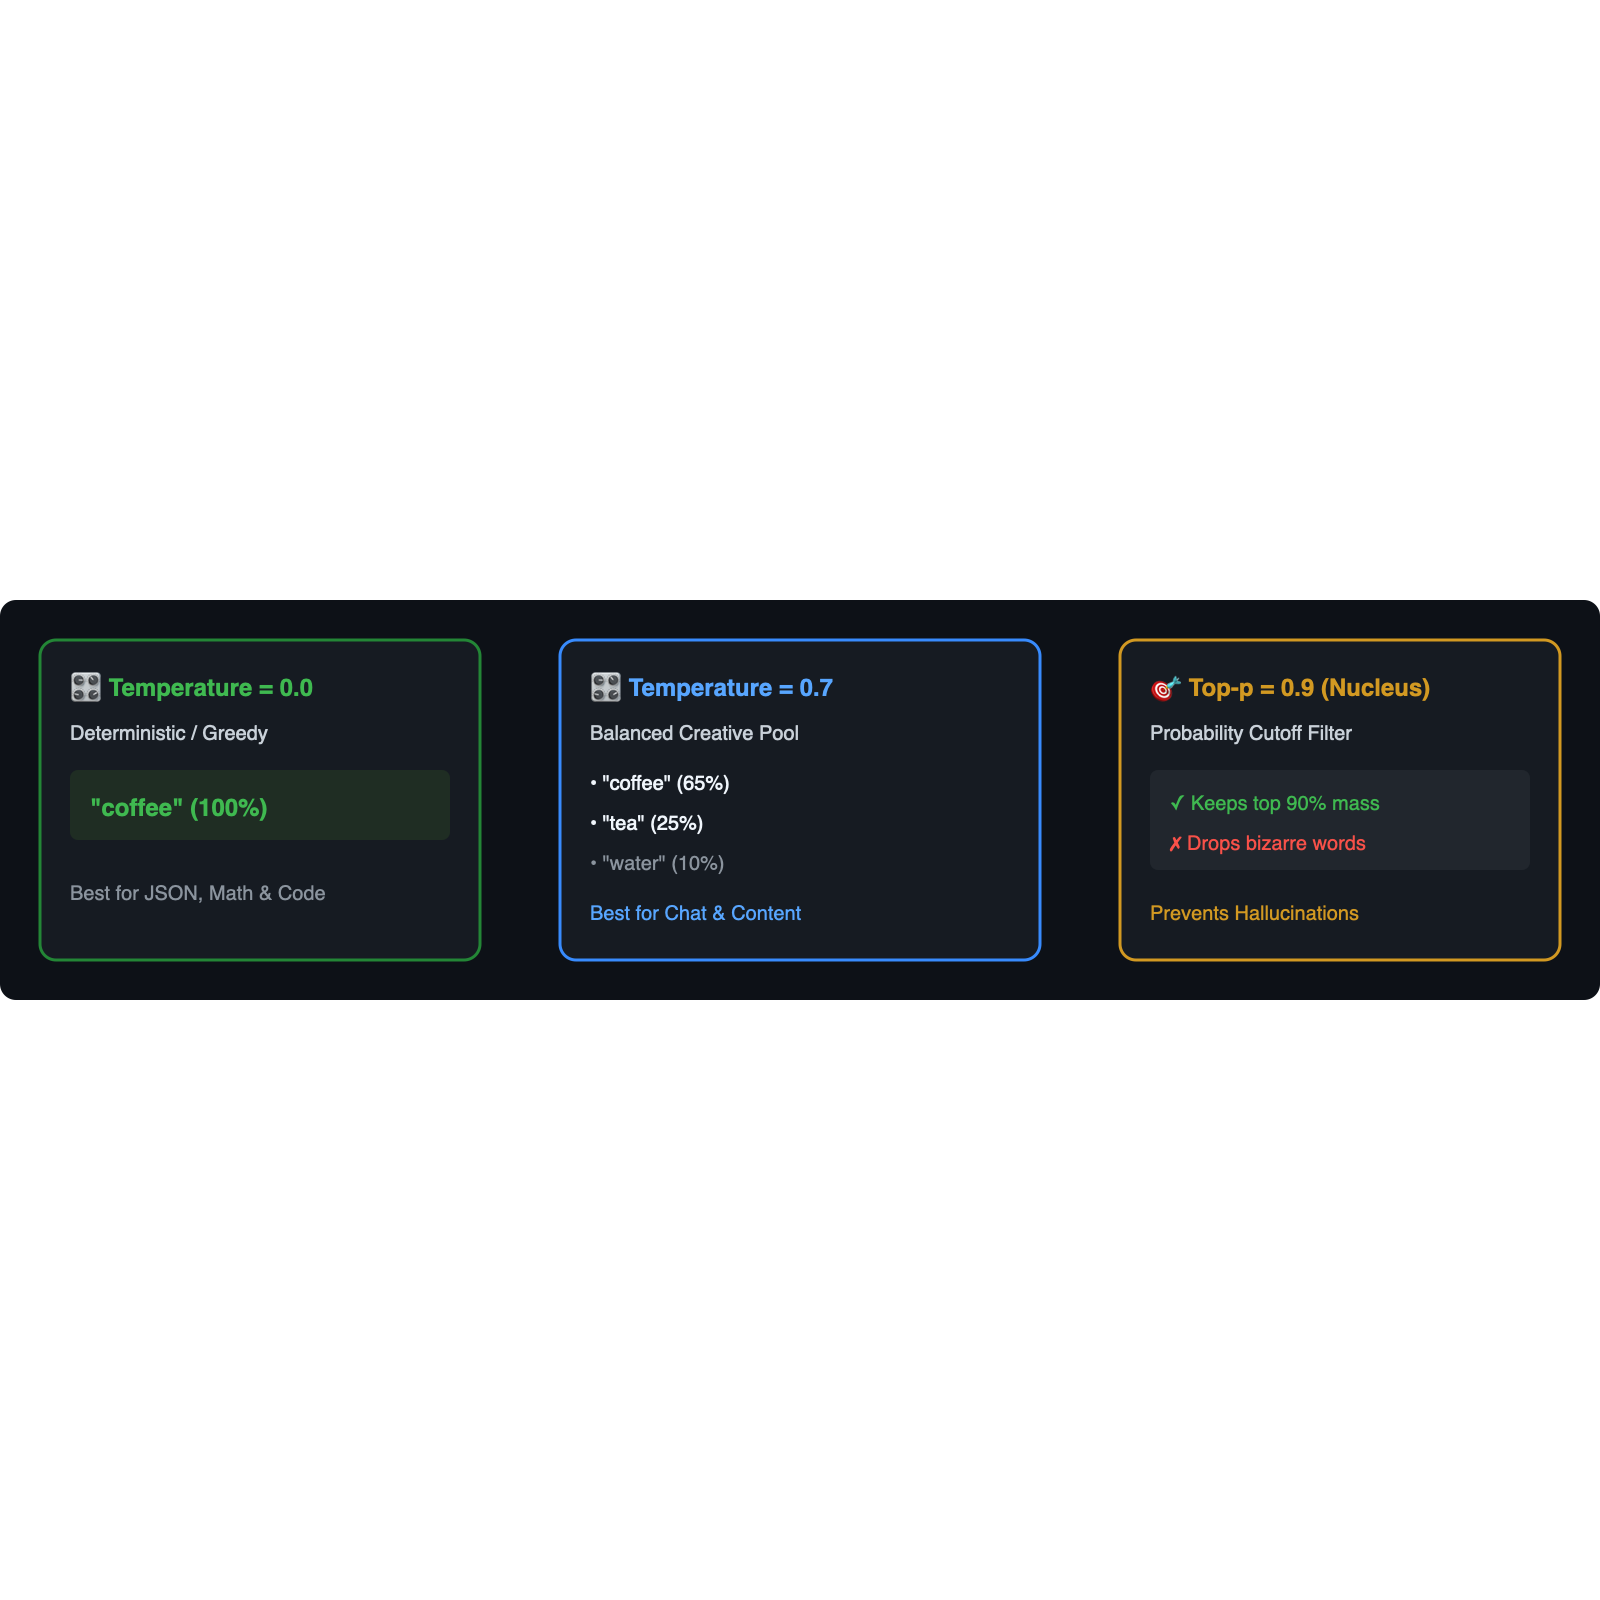
</p>

---

### 🎛️ The 3 Essential Sampling Parameters:

| Parameter | What It Controls | Recommended Value | When to Use |
| :--- | :--- | :--- | :--- |
| **`temperature`** | Randomness / Creativity | `0.0` to `1.0` | **`0.0`**: JSON data extraction, math, coding, factual Q&amp;A.<br>**`0.7`**: General conversation, copywriting, brainstorming.<br>**`1.2+`**: Creative writing, poetry, wild ideation. |
| **`top_p`** (Nucleus) | Cumulative probability pool | `0.9` to `0.95` | Cuts off the long tail of bizarre words while keeping creative flexibility. |
| **`top_k`** | Fixed number of top tokens | `40` to `64` | Restricts candidate words to the top $k$ highest scoring choices. |

Let's run a live Python test to see the difference between `temperature=0.0` (factual) and `temperature=1.0` (creative) on the exact same prompt!


In [ ]:
# Demonstrating Deterministic vs Creative Generation Modes

prompt = "Explain the significance of the KV-cache in large language model inference in two concise paragraphs."

# 1. Deterministic / Low Temperature Configuration
config_deterministic = types.GenerateContentConfig(
    temperature=0.0,
    top_p=0.1,
    max_output_tokens=300,
    system_instruction="You are a Principal AI Hardware Systems Architect. Be precise, technical, and concise."
)

response_det = client.models.generate_content(
    model="gemini-3.8-flash",
    contents=prompt,
    config=config_deterministic
)

print("="*40 + " [DETERMINISTIC: Temp=0.0] " + "="*40)
print(response_det.text)

# 2. Creative / Exploratory Configuration
config_creative = types.GenerateContentConfig(
    temperature=1.2,
    top_p=0.95,
    max_output_tokens=300,
    system_instruction="You are an enthusiastic computer science educator using vivid analogies."
)

response_creat = client.models.generate_content(
    model="gemini-3.8-flash",
    contents=prompt,
    config=config_creative
)

print("\n" + "="*40 + " [CREATIVE: Temp=1.2] " + "="*40)
print(response_creat.text)


---
## 5. Post-Training: Turning a Raw Predictor into a Helpful Assistant

A base pre-trained model is just a raw document completer. If you ask it: `"What is the capital of France?"`, it might complete it with: `" and what is the capital of Germany? A geography quiz for 5th graders."`

**Post-Training** is the process of teaching the model how to act like a helpful, honest, and harmless assistant.

<p align="center">
  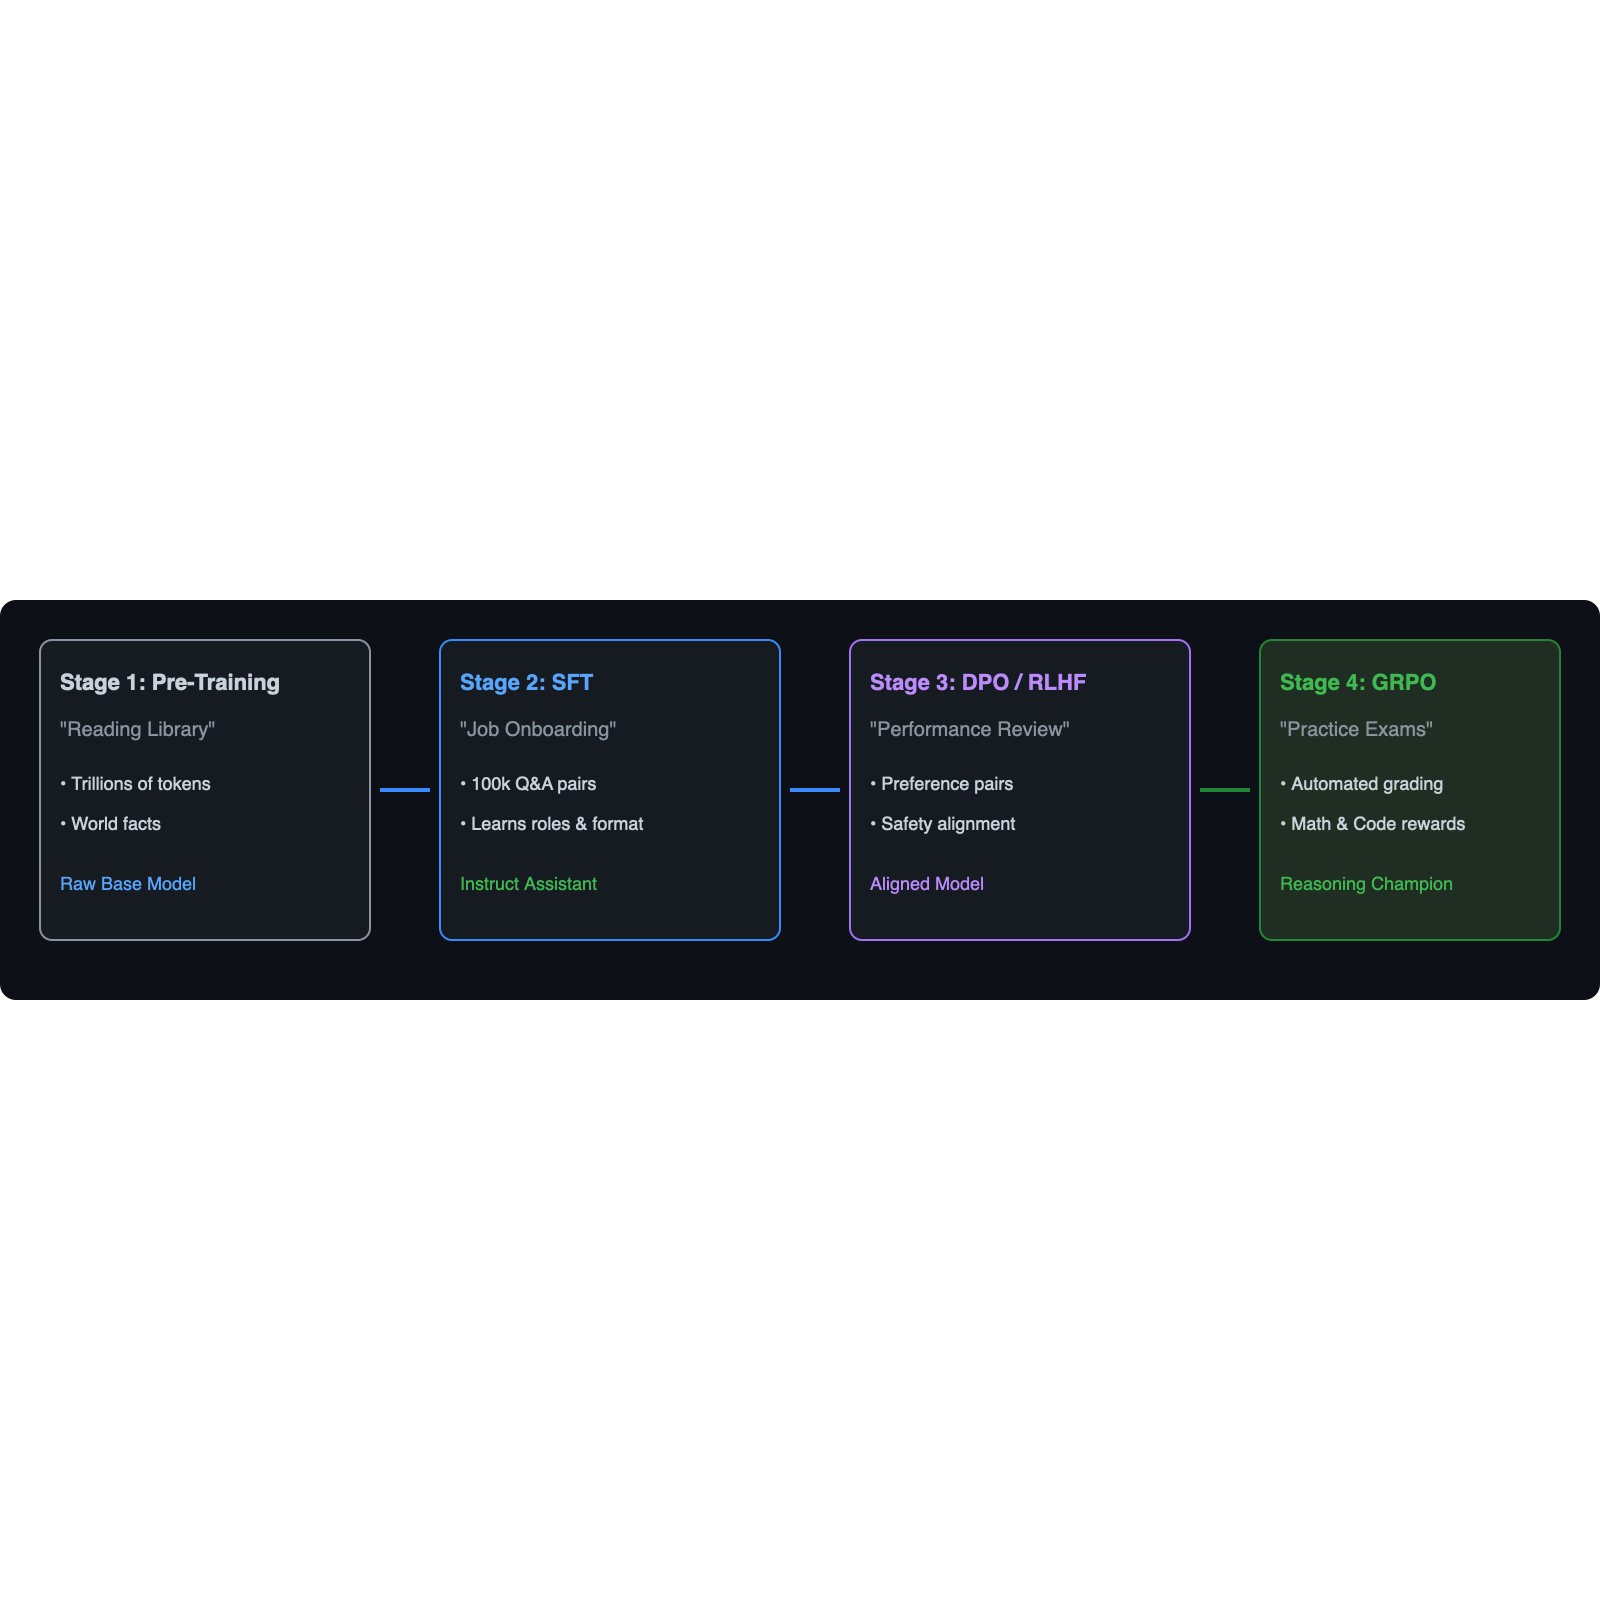
</p>

---

### 🔍 Post-Training Comparison for Applied AI Engineers:

| Technique | Full Name | How It Works | Best Used For |
| :--- | :--- | :--- | :--- |
| **SFT** | Supervised Fine-Tuning | Training on exact prompt-response target pairs. | Teaching specific response formats, schemas, and tone. |
| **DPO** | Direct Preference Optimization | Mathematically pushes the model toward preferred answers without needing a separate reward model. | General helpfulness, conversational style, and safety guardrails. |
| **GRPO** | Group Relative Policy Optimization | Generates a group of candidate reasoning paths and rewards the best verifiable results. | Math, coding, and multi-step reasoning (e.g. Gemini Thinking, DeepSeek-R1). |


---
## 6. How Do We Measure AI Quality? Benchmarks & Evaluation

How do you know if one model is actually better than another? In Applied AI Engineering, we evaluate models across 4 key dimensions:

<p align="center">
  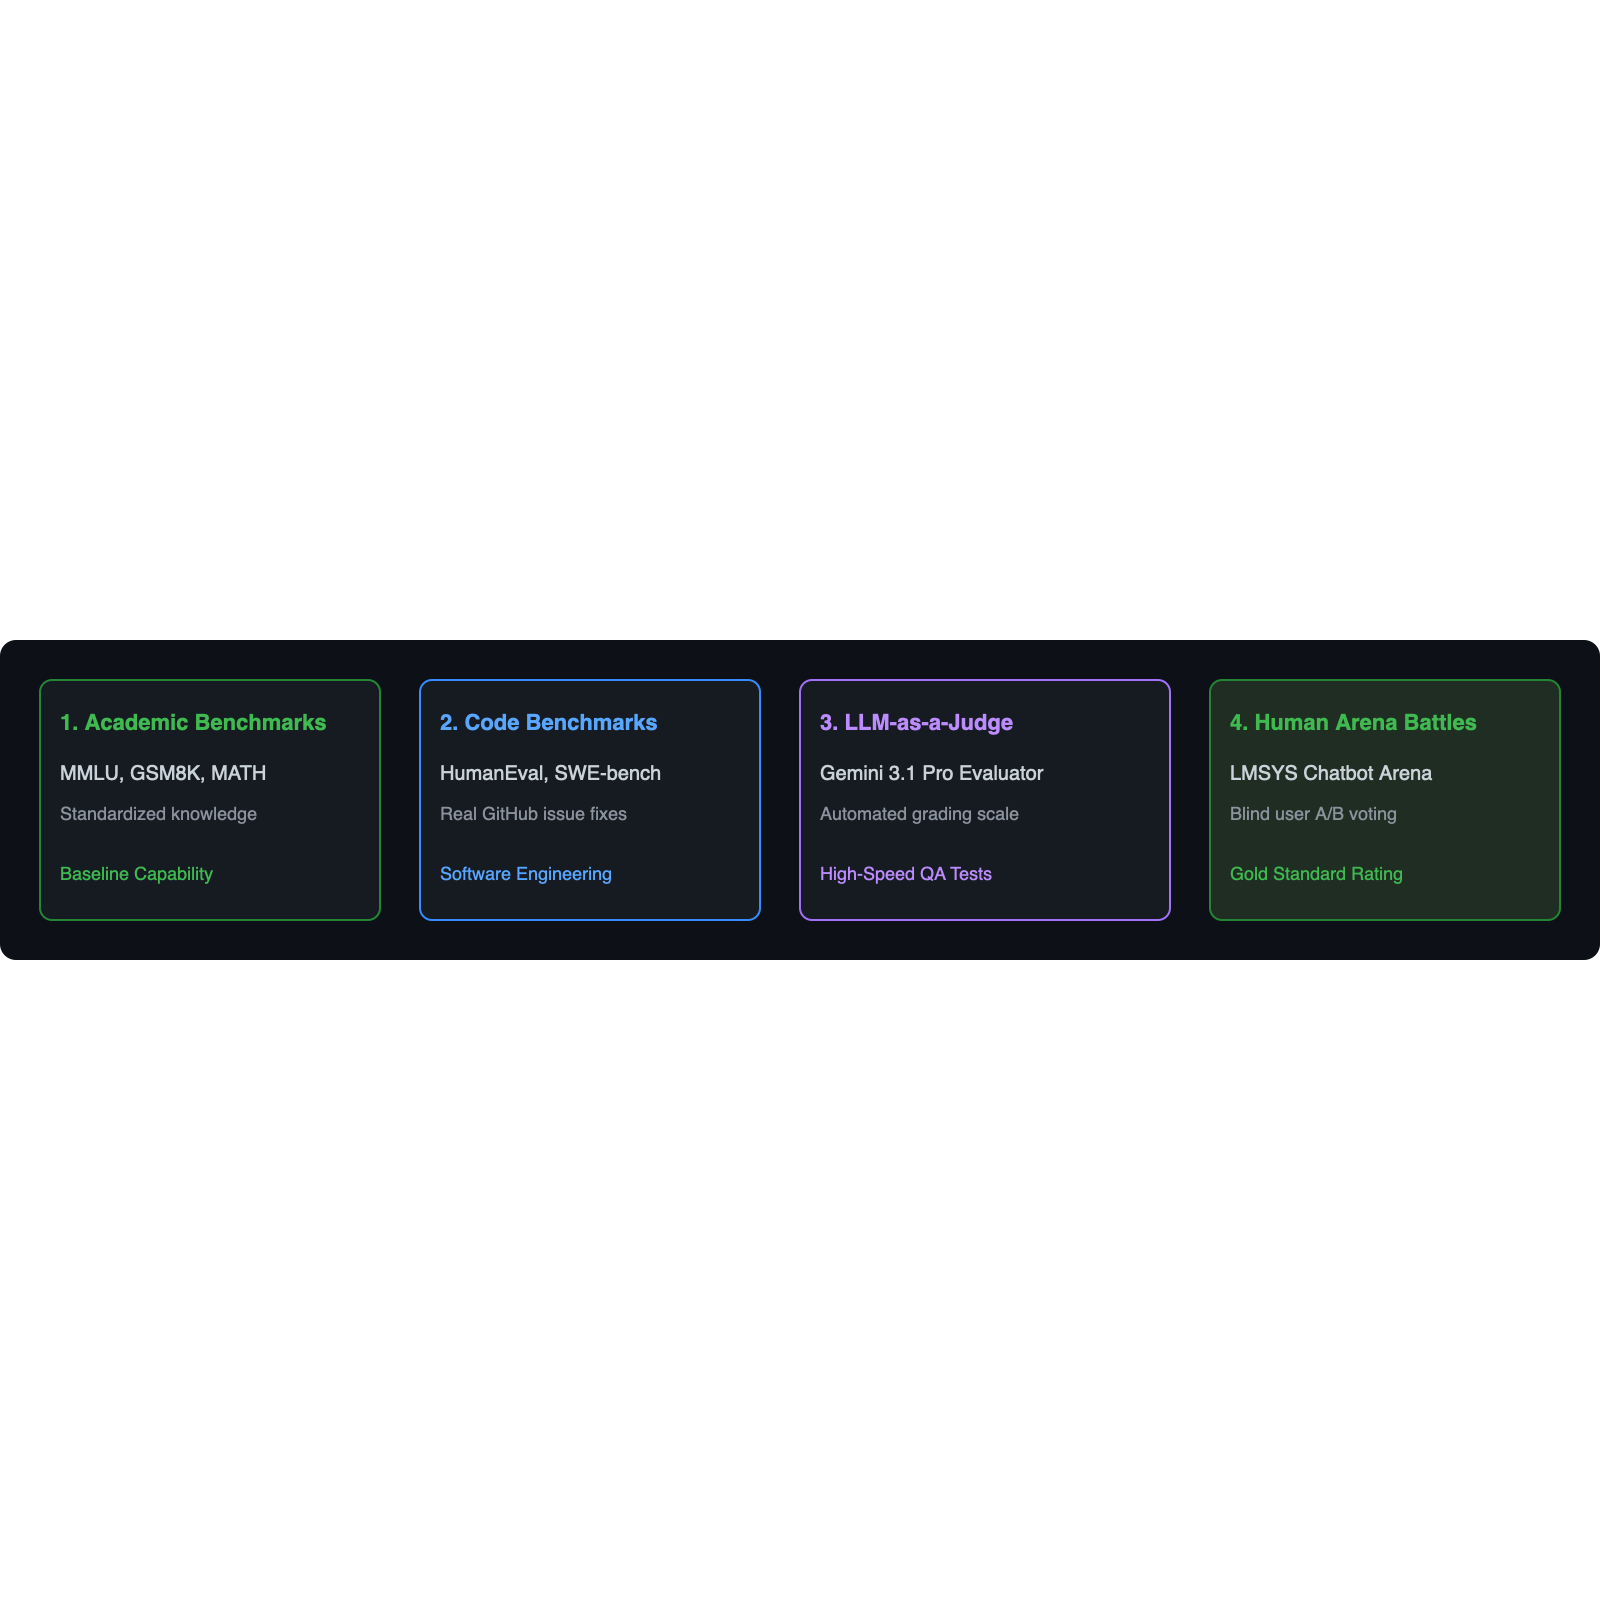
</p>

| Benchmark | What It Tests | Real-World Meaning |
| :--- | :--- | :--- |
| **MMLU / MMLU-Pro** | Multi-subject exam questions (Law, Medicine, History) | Overall world knowledge &amp; facts |
| **GSM8K &amp; MATH** | Multi-step grade school math &amp; olympiad math | Logical reasoning and deduction |
| **SWE-bench** | Resolving real GitHub issues in Python repos | Practical software engineering capability |
| **LMSYS Arena** | Real user head-to-head blind voting | How natural and helpful users feel the model is |

Let's inspect how Google Gemini tracks token counts and usage metadata:


In [ ]:
# Inspecting Token Counts & Metadata with google-genai

sample_prompt = """
Write a Python function implementing an LRU Cache with O(1) time complexity
for both get() and put() operations using a doubly linked list and a hash map.
"""

# Count tokens before sending request
count_resp = client.models.count_tokens(
    model="gemini-3.8-flash",
    contents=sample_prompt
)
print(f"📊 Input Token Count: {count_resp.total_tokens} tokens")

# Generate and inspect usage metadata
response = client.models.generate_content(
    model="gemini-3.8-flash",
    contents=sample_prompt,
    config=types.GenerateContentConfig(max_output_tokens=600)
)

print(f"⚡ Prompt Tokens: {response.usage_metadata.prompt_token_count}")
print(f"⚡ Candidates (Output) Tokens: {response.usage_metadata.candidates_token_count}")
print(f"⚡ Total Tokens: {response.usage_metadata.total_token_count}")


---
## 7. Hands-on Implementation: The Gemini Playground Engine

Now, let's engineer a modular, interactive **LLM Playground** that supports:
- Real-time token streaming
- Multi-turn conversation state persistence
- Dynamic temperature, Top-$p$, Top-$k$, and token budget tweaking
- System persona switching
- Side-by-side model comparison (`gemini-3.8-flash` vs `gemini-3.1-pro-preview`)


In [ ]:
import time
from typing import Generator, List, Dict, Any

class GeminiPlaygroundEngine:
    """Production-grade abstraction for interactive LLM experimenting."""
    
    def __init__(self, client: genai.Client, default_model: str = "gemini-3.8-flash"):
        self.client = client
        self.default_model = default_model
        self.history: List[Dict[str, str]] = []
        
    def stream_generate(
        self,
        prompt: str,
        model: str = None,
        system_instruction: str = None,
        temperature: float = 0.7,
        top_p: float = 0.95,
        top_k: int = 40,
        max_output_tokens: int = 1024,
    ) -> Generator[str, None, None]:
        """Streams generated tokens in real-time."""
        target_model = model or self.default_model
        config = types.GenerateContentConfig(
            system_instruction=system_instruction,
            temperature=temperature,
            top_p=top_p,
            top_k=top_k,
            max_output_tokens=max_output_tokens
        )
        
        response_stream = self.client.models.generate_content_stream(
            model=target_model,
            contents=prompt,
            config=config
        )
        
        for chunk in response_stream:
            if chunk.text:
                yield chunk.text

    def compare_models(
        self,
        prompt: str,
        models: List[str] = ["gemini-3.8-flash", "gemini-3.1-pro-preview"],
        system_instruction: str = "You are an expert technical consultant. Answer concisely."
    ) -> Dict[str, Dict[str, Any]]:
        """Runs comparative inference across multiple models and benchmarks latency."""
        results = {}
        for mod in models:
            start_time = time.time()
            try:
                resp = self.client.models.generate_content(
                    model=mod,
                    contents=prompt,
                    config=types.GenerateContentConfig(
                        system_instruction=system_instruction,
                        temperature=0.2,
                        max_output_tokens=500
                    )
                )
                latency = time.time() - start_time
                results[mod] = {
                    "text": resp.text,
                    "latency_sec": round(latency, 2),
                    "prompt_tokens": resp.usage_metadata.prompt_token_count,
                    "output_tokens": resp.usage_metadata.candidates_token_count,
                    "error": None
                }
            except Exception as e:
                results[mod] = {"error": str(e), "latency_sec": round(time.time() - start_time, 2)}
        return results

# Instantiate engine
playground = GeminiPlaygroundEngine(client)
print("🚀 GeminiPlaygroundEngine instantiated successfully.")


In [ ]:
# Demonstration: Streaming response
print("📡 Live Streaming Token Output:")
print("-" * 60)
for chunk in playground.stream_generate(
    prompt="Explain the difference between Softmax with Temperature and Nucleus (Top-p) Sampling in 3 bullet points.",
    temperature=0.3
):
    print(chunk, end="", flush=True)
print("\n" + "-" * 60)


In [ ]:
# Demonstration: Model Comparison Benchmark
test_prompt = "Write a concise Python one-liner to invert a dictionary with unique values, and analyze its time/space complexity."
comparison = playground.compare_models(test_prompt, models=["gemini-3.8-flash", "gemini-3.1-pro-preview"])

for model_name, data in comparison.items():
    print(f"\n==================== [MODEL: {model_name}] (Latency: {data['latency_sec']}s) ====================")
    if data['error']:
        print(f"❌ Error: {data['error']}")
    else:
        print(f"Tokens: Prompt={data['prompt_tokens']} | Output={data['output_tokens']}")
        print(data['text'])


---
## 8. Practical Hands-On Exercises (With Beginner Hints & Starter Code)

Test your understanding by completing these three practical exercises. Try implementing them yourself before checking the solutions below!

---

### 🎯 Exercise 1.1: Token Compression Ratio Calculator
**The Goal**: Understand how models slice different languages into tokens.
- **Why it matters**: In English, 1 token is roughly 4 characters (0.75 words). In non-Latin scripts (Japanese, Hindi, Arabic) or Python code, token counts can vary significantly. As an Applied AI engineer, this directly impacts your API bill and context limits!
- **Task**: Implement `calculate_compression_ratio(text: str, model: str = "gemini-3.8-flash")` to return character count, byte count, token count, and ratios.
- **💡 Beginner Hint**: Use `client.models.count_tokens(model=model, contents=text).total_tokens` to get the exact token count!

---

### 🎯 Exercise 1.2: Temperature Sampling Distribution Simulator
**The Goal**: Write pure Python math to see how Temperature and Top-p actually change probabilities.
- **Why it matters**: Understanding the softmax equation will make you confident in choosing sampling settings for production apps.
- **Task**: Implement `simulate_sampling_probabilities(logits: List[float], temperature: float, top_p: float = 1.0, top_k: int = 0)`.
- **💡 Beginner Hint**: 
  1. Divide logits by temperature: `scaled = [z / temperature for z in logits]`.
  2. Compute exponents: `exp_vals = [math.exp(z - max_z) for z in scaled]`.
  3. Normalize by sum: `probs = [v / sum(exp_vals) for v in exp_vals]`.

---

### 🎯 Exercise 1.3: Token Budget-Guarded Multi-Turn Chat Session
**The Goal**: Prevent long chat sessions from running out of memory or blowing up API costs.
- **Why it matters**: Production customer chatbots can talk for 50+ turns. If you don't manage context windows, requests will become slow and expensive.
- **Task**: Create a `TokenBudgetChatSession` class that tracks token usage across turns and prunes or warns when exceeding a budget (e.g. 2,000 tokens).
- **💡 Beginner Hint**: Keep a list of message turns and check token count after each interaction.


---
## 9. Comprehensive Step-by-Step Solutions & Architectural Explanations

Here are the complete production-grade implementations for each exercise with in-depth technical commentary.


In [ ]:
# ============================================================================
# SOLUTION 1.1: Token Compression Ratio Calculator
# ============================================================================
def calculate_compression_ratio(text: str, model: str = "gemini-3.8-flash") -> Dict[str, Any]:
    """
    Analyzes the tokenization efficiency of Gemini's SentencePiece/BPE tokenizer.
    Higher bytes-per-token indicates greater lexical efficiency.
    """
    char_count = len(text)
    byte_count = len(text.encode('utf-8'))
    
    # Query Gemini Token Counter
    count_resp = client.models.count_tokens(model=model, contents=text)
    token_count = count_resp.total_tokens
    
    chars_per_token = round(char_count / max(token_count, 1), 2)
    bytes_per_token = round(byte_count / max(token_count, 1), 2)
    
    return {
        "text_preview": text[:40] + ("..." if len(text) > 40 else ""),
        "char_count": char_count,
        "byte_count": byte_count,
        "token_count": token_count,
        "chars_per_token": chars_per_token,
        "bytes_per_token": bytes_per_token
    }

# Test across distinct domains
test_samples = [
    "Standard English conversational text with everyday vocabulary.",
    "def fibonacci(n: int) -> int: return n if n <= 1 else fibonacci(n-1) + fibonacci(n-2)",
    r"\int_{-\infty}^{\infty} e^{-x^2} dx = \sqrt{\pi}",
    "人工知能と大規模言語モデルの最先端技術について学ぶ。"
]

print("📊 Tokenizer Efficiency Breakdown:")
for sample in test_samples:
    res = calculate_compression_ratio(sample)
    print(f"• [{res['text_preview']}] -> Tokens: {res['token_count']} | Bytes/Tok: {res['bytes_per_token']} | Chars/Tok: {res['chars_per_token']}")


In [ ]:
# ============================================================================
# SOLUTION 1.2: Temperature & Nucleus (Top-p) Sampling Simulator
# ============================================================================
import numpy as np

def simulate_sampling_probabilities(
    logits: List[float],
    temperature: float = 1.0,
    top_p: float = 1.0,
    top_k: int = 0
) -> np.ndarray:
    """
    Simulates the exact logit transformation pipeline of modern LLM inference engines.
    
    Steps:
    1. Temperature Scaling: z_scaled = z / T
    2. Top-k Filtering: Zero out logits outside top-k
    3. Softmax Normalization
    4. Top-p (Nucleus) Truncation: Keep tokens up to cumulative sum >= p
    5. Final Re-normalization
    """
    z = np.array(logits, dtype=np.float64)
    
    # Step 1: Temperature Scaling
    if temperature <= 1e-5:
        # Greedy decoding simulation
        probs = np.zeros_like(z)
        probs[np.argmax(z)] = 1.0
        return probs
    
    z_scaled = z / temperature
    
    # Step 2: Top-k filtering
    if top_k > 0 and top_k < len(z):
        indices_to_remove = z_scaled < np.partition(z_scaled, -top_k)[-top_k]
        z_scaled[indices_to_remove] = -np.inf
        
    # Step 3: Numerically Stable Softmax
    exp_z = np.exp(z_scaled - np.max(z_scaled))
    probs = exp_z / np.sum(exp_z)
    
    # Step 4: Top-p (Nucleus) Filtering
    if top_p < 1.0:
        sorted_indices = np.argsort(probs)[::-1]
        sorted_probs = probs[sorted_indices]
        cumulative_probs = np.cumsum(sorted_probs)
        
        # Identify indices exceeding top_p threshold
        cutoff_mask = cumulative_probs > top_p
        # Shift mask right by 1 to include the first token exceeding threshold
        cutoff_mask[1:] = cutoff_mask[:-1]
        cutoff_mask[0] = False
        
        indices_to_zero = sorted_indices[cutoff_mask]
        probs[indices_to_zero] = 0.0
        
        # Step 5: Final Re-normalization
        probs = probs / np.sum(probs)
        
    return probs

# Test Simulation
sample_logits = [12.0, 11.5, 9.0, 6.0, 3.0, 1.0, 0.5]
vocab_tokens = ["the", "a", "an", "this", "some", "quantum", "galaxy"]

print("🔬 Sampling Distribution Simulation:")
for temp in [0.001, 0.5, 1.0, 2.0]:
    p = simulate_sampling_probabilities(sample_logits, temperature=temp, top_p=0.9)
    top_token = vocab_tokens[np.argmax(p)]
    print(f"• Temp={temp:<5} -> Top Token: '{top_token}' (Prob: {np.max(p):.4f}) | Full Probs: {np.round(p, 3)}")


In [ ]:
# ============================================================================
# SOLUTION 1.3: Token Budget-Guarded Multi-Turn Chat Session
# ============================================================================
class TokenBudgetChatSession:
    """
    Enterprise-grade stateful chat session with automatic token counting
    and history pruning to prevent context overflow.
    """
    
    def __init__(
        self,
        client: genai.Client,
        model: str = "gemini-3.8-flash",
        max_budget_tokens: int = 2048,
        system_instruction: str = "You are a senior technical advisor."
    ):
        self.client = client
        self.model = model
        self.max_budget_tokens = max_budget_tokens
        self.system_instruction = system_instruction
        self.chat = self.client.chats.create(
            model=self.model,
            config=types.GenerateContentConfig(system_instruction=self.system_instruction)
        )
        self.message_history = []
        
    def send_message(self, user_text: str) -> str:
        # Pre-check token budget
        history_str = "\n".join([f"{m['role']}: {m['text']}" for m in self.message_history]) + f"\nuser: {user_text}"
        tokens = self.client.models.count_tokens(model=self.model, contents=history_str).total_tokens
        
        # History pruning if exceeding 80% of budget
        while tokens > (self.max_budget_tokens * 0.8) and len(self.message_history) > 2:
            pruned = self.message_history.pop(0)
            print(f"⚠️ [Token Budget Guard] Pruned oldest turn from history: {pruned['role']} ({len(pruned['text'])} chars)")
            history_str = "\n".join([f"{m['role']}: {m['text']}" for m in self.message_history]) + f"\nuser: {user_text}"
            tokens = self.client.models.count_tokens(model=self.model, contents=history_str).total_tokens
            
        # Send message to Gemini Chat
        response = self.chat.send_message(user_text)
        
        # Record history
        self.message_history.append({"role": "user", "text": user_text})
        self.message_history.append({"role": "assistant", "text": response.text})
        
        total_toks = response.usage_metadata.total_token_count if response.usage_metadata else tokens
        print(f"💬 [Turn Completed] Current Context Tokens: {total_toks}/{self.max_budget_tokens}")
        return response.text

# Test the session
chat_session = TokenBudgetChatSession(client, max_budget_tokens=1500)
resp1 = chat_session.send_message("Explain the difference between PPO and DPO in reinforcement learning.")
print(f"Assistant: {resp1[:150]}...")


---
## Summary & Key Takeaways
1. **Pre-Training**: Determines model capability, knowledge bounds, and tokenization efficiency via BPE and transformer scaling laws.
2. **Post-Training**: SFT and RLHF/DPO align raw completions into obedient, helpful, and verifiable problem solvers.
3. **Inference Control**: Temperature, Top-$p$, Top-$k$, and system instructions provide deterministic control over the generative process.
4. **Next Step**: In **Project 2**, we build an advanced Enterprise Customer Support Chatbot using **RAG (Retrieval-Augmented Generation)**, Vector Embeddings, Hybrid Search, and Grounded Verification!
